CHAPTER. 5장
회귀

01. 회귀 소개

데이터 값이 평균과 같은 일정한 값으로 돌아가려는 경향을 이용한 통계학 기법
여러 개의 독립변수와 한 개의 종속 변수 간의 상관관계를 모델링하는 기법
독립변수: 피처
종속변수: 결정 값
머신러닝 회귀 예측의 핵심: 주어진 피처와 결정 값 데이터 기반에서 학습을 통해 최적의 회귀 계수를 찾아내는 것

지도학습
-분류 :이산값
-회귀 :연속값

[선형회귀]
실제값과 예측값의 차이를 최소화하는 직선형 회귀선을 최적화하는 방식
- 일반선형회귀 : 예측값과 실제값의 RSS를 최소화할 수 있도록 회귀 계수를 최적화하며, 규제 적용 X
- 릿지 : 선형 회귀에 L2 규제를 추가한 회귀 모델 (*L2: 상대적으로 큰 회귀 계수 값의 예측 영향도를 감소시키기 위해 회귀 계수값을 더 작게 만드는 규제모델)
- 라쏘 : 선형 회귀에 L1 규제를 추가한 회귀 모델(*L1: 예측 영향력이 작은 피처의 회귀 계수를 0으로 만들어 회귀 예측 시 피처가 선택되지 않도록 함 => 피처 선택 기능)
- 엘라스틱넷 : L2,L1 규제 결합 / 피처가 많은 데이터 세트에 적용 / L1으로 피처 개수 줄이고 L2 규제로 계수 값의 크기 조정
- 로지스틱 회귀 : 분류에 사용되는 선형 모델/ 이진 분류뿐 아니라 희소 영역의 분류와 같은 영역에서 뛰어난 예측 성능
(*규제: 일반적인 선형 회귀의 과적합 문제 해결을 위해 회귀 계수의 페널티값 적용)

02. 단순 선형 회귀를 통한 회귀 이해

단순 선형 회귀: 독립변수, 종속변수 각각 1개
잔차 : 실제 값과 회귀 모델 차이에 따른 오류
최적의 회귀 모델 : 잔차 최소인 모델 / 최소가 되도록 하는 최적의 회귀 모델 계수 
RSS : 오류 구하는 방식 / 오류 갑스이 제곱을 구해서 더하는 방식 / 비용함수 (손실함수Loss Function)

03. 비용 최소화하기 - 경사 하강법

경사 하강법 : 반복적인 계산을 통해 W 파라미터 값을 업데이트 하면서 오류 값이 최소가 되는 W 파라미터를 구하는 방식
[비용함수가 포물선 형태의 2차 함수라면 최초 w에서 미분을 적용한 뒤 미분 값이 감소하는 방향으로 w 업데이트, 더 이상 감소하지 않는 지점을 최소로 간주하고 w 반환]

In [1]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


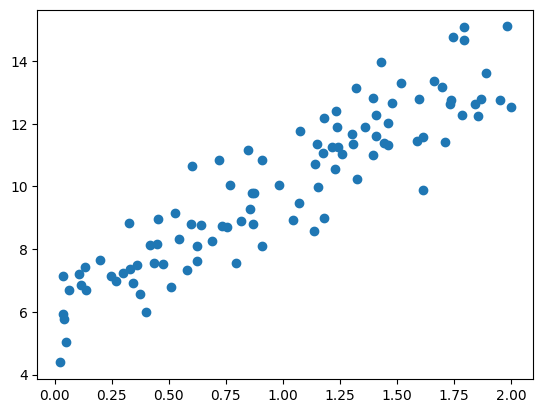

In [3]:
#y=4x+6을 근사하기 위한 100개의 데이터 세트를 만들고 경사하강법을 이용한 회귀 계수 도출

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 
# 그래프를 따로 창으로 띄우지 않고, 노트북 안에 바로 표시


np.random.seed(0) #seed 설정하면 다시 실행해도 항상 같은 값 나옴

noise = np.random.randn(100,1)
X = 2 * np.random.rand(100,1)
y = 6 + 4 * X + noise

plt.scatter(X, y)

In [7]:
def get_cost(y,y_pred):
    N=len(y)
    cost=np.sum(np.square(y-y_pred))/N
    return cost

In [10]:
# w1과 w0를 업데이트할 w1_update, w0_update를 반환하는 함수 생성
def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
    
    N = len(y)
    
    # w1_update, w0_update를 먼저 w1, w0의 shape와 동일한 크기를 가진 0값으로 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
     # 예측 배열 계산, 예측과 실제값의 차이 계산
    y_pred = np.dot(X, w1.T) + w0
    diff = y - y_pred
    
    # w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성
    w0_factors = np.ones((N,1))
    
    # w1과 w0를 업데이트할 w1_update, w0_update 계산
    w1_update = -(2/N) * learning_rate * (np.dot(X.T, diff))
    w0_update = -(2/N) * learning_rate * (np.dot(w0_factors.T, diff))
    
    return w1_update, w0_update

In [11]:
# get_weight_updates 함수를 이용해 경사 하강 방식으로 반복적으로 수행하여 w1, w0를 업데이트하는 함수 생성

# 입력 인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0를 업데이트
def gradient_descent_steps(X, y, iters=10000):
    
    # w0와 w1을 모두 0으로 초기화
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    
    # 인자로 주어진 iters만큼 반복적으로 get_weight_updates()를 호출해 w1, w0 업데이트 수행
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
        
    return w1, w0

In [12]:
# 비용함수 값 계산

def get_cost(y, y_pred):
    N = len(y)
    cost = np.sum(np.square(y - y_pred)) / N
    return cost

# 회귀계수 계산
w1, w0 = gradient_descent_steps(X, y, iters=1000)
print('w1:{0:.3f}, w0:{1:.3f}'.format(w1[0,0], w0[0,0]))

# 비용함수 값 계산
y_pred = w1[0,0] * X + w0
print('cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1:4.028, w0:6.020
cost:1.0169


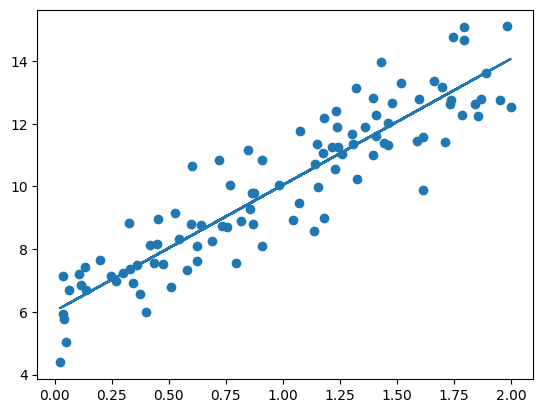

In [13]:
plt.scatter(X, y)
plt.plot(X, y_pred)

경사하강법 단점 : 수행 시간 오래걸림
-> 확률적 경사 하강법 이용
[확률적 경사 하강법]
: 전체 입력 데이터로 w가 업데이트 되는 값을 계산하는 것이 아니라 일부 데이터만 이용해 w가 업데이트 되는 값을 계산하므로 경사 하강법에 비해 빠른 속도 보장

In [14]:
def stochastic_gradient_descent_steps(X, y, batch_size=10, iters=1000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    
    for ind in range(iters):
        np.random.seed(ind)
        
        # 전체 X, y 데이터에서 랜덤하게 batch_size만큼 데이터를 추출해 sample_X, sample_y로 저장
        stochastic_random_index = np.random.permutation(X.shape[0]) # shuffle된 배열 생성
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]
        
        # 랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
        
    return w1, w0

In [15]:
w1, w0 = stochastic_gradient_descent_steps(X, y, iters=1000)
print('w1:', round(w1[0,0], 3), 'w0:', round(w0[0,0], 3))

y_pred = w1[0,0] * X + w0
print('cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1: 3.999 w0: 5.971
cost:1.0240


04. 사이킷런 LinearRegression을 이용한 보스턴 주택 가격 예측

[LinearRegression 클래스 - ordinary Least Squares]
: 예측 값과 실제 값의 RSS를 최소화해 OLS 추정 방식으로 구현한 클래스

class sklearn.linear_model.LinearRegression(fit_intercept=True, normalize=False, copy_X=True, n_jobs=1)

OLS기반 회귀 계수 계산은 입력 피처의 독립성에 많은 영향을 줌
-> 피처 간의 상관관계가 매우 높은 경우 분산이 매우 커져 오류에 민감해짐 = 다중공간성 문제
상관관계가 높은 피처가 많은 경우 독립적인 중요한 피처만 남기고 제거하거나 규제 적용

[회귀 평가 지표]
- MAE : 실제값과 예측값 차이를 절댓값으로변환해 평균낸 값
- MSE : 실제값과 예측값의 차이를 제곱해 평균한 것
- RMSE : MSE 값은 오류의 제곱을 구하므로 실제 오류평균보다 더 커지는 특성이 있으므로 MSE에 루트를 씌운 것
- R^2 : 분산 기반으로 예측 성능 평가, 실제 값의 분산 대비 예측값의 분산 비율을 지표로 하며, 1에 가까울수록 예측 정확도 높음

<scoring 함수에 회귀 평가 지표 적용 시 주의점>
: scoring은 값이 클수록 좋은 모델이라고 판단
-> 작을수록 좋은 지표는 음수 형태로 바꿔 보정

In [18]:
!pip install seaborn

In [4]:
import sys
!{sys.executable} -m pip install joblib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
scikit-learn 1.8.0 requires threadpoolctl>=3.2.0, which is not installed.


In [6]:
import sys
!{sys.executable} -m pip install threadpoolctl

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_boston
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

# boston 데이터 세트 로드
boston = load_boston()

# boston 데이터 세트 DataFrame 변환
bostonDF = pd.DataFrame(boston.data, columns=boston.feature_names)

# boston 데이터 세트의 target array는 주택 가격. 이를 PRICE 컬럼으로 DataFrame에 추가
bostonDF['PRICE'] = boston.target
bostonDF.head()

ImportError: DLL load failed while importing _fblas: 지정된 모듈을 찾을 수 없습니다.

In [ ]:
# 2X4 subplots 이용. axs는 4*2개의 ax를 가짐
fig, axs = plt.subplots(figsize=(16,8), ncols=4, nrows=2)

lm_features = ['RM', 'ZN', 'INDUS','NOX', 'AGE', 'PTRATIO', 'LSTAT', 'RAD']

for i, feature in enumerate(lm_features):
    row = int(i/4) # 나누기
    col = i%4 # 나머지
    sns.regplot(x=feature, y='PRICE', data=bostonDF, ax=axs[row][col])

In [ ]:
bostonDF.isnull().sum()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

y_target = bostonDF['PRICE']
X_features = bostonDF.drop(['PRICE'], axis=1, inplace=False)

X_train, X_test, y_train, y_test = train_test_split(X_features, y_target, test_size=0.3, random_state=156)

# LinearRegression으로 학습/예측/평가 수행
lr = LinearRegression()
lr.fit(X_train, y_train)
y_preds = lr.predict(X_test)
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE:{0:.3f}, RMSE:{1:.3f}'.format(mse, rmse))
print('Variance score:{0:.3f}'.format(r2_score(y_test, y_preds)))

In [ ]:
print('절편:', lr.intercept_)
print('회귀계수:', np.round(lr.coef_, 1))

In [ ]:
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_features.columns)
coeff.sort_values(ascending=False)

In [ ]:
from sklearn.model_selection import cross_val_score

y_target = bostonDF['PRICE']
X_features = bostonDF.drop(['PRICE'], axis=1, inplace=False)
lr = LinearRegression()

mse_scores = -cross_val_score(lr, X_features, y_target, scoring='neg_mean_squared_error', cv=5)
rmse_scores = np.sqrt(mse_scores)
avg_rmse = np.mean(rmse_scores)

print('5folds의 개별 mse scores:', np.round(mse_scores, 2))
print('5folds의 개별 rmse scores:', np.round(rmse_scores, 2))
print('5folds의 평균 rmse:{0:.3f}'.format(avg_rmse))

In [ ]:
05. 다항 회귀와 과적합/과소적합 이해

[다항회귀 이해]
다항회귀: 독립변수가 단항식이 아닌 다항식 / 선형회귀
->직선형보다 예측 성능 높음

사이킷런은 다항 회귀를 위한 클래스를 명시적으로 제공하지 않음
그러나, 다항 회귀 역시 선형 회귀이므로 비선형 함수를 선형 모델에 적용시키는 방법을 사용해 구현
-> PolynomialFeature 클래스를 통해 피처를 Polynomial(다항식) 피처로 변환
[degree파라미터를 통해 입력 받은 단항식 피처를 degree에 해당하는 다항식 피처로 변환]

In [1]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 단항식 생성, [[0,1],[2,3]]의 2X2 행렬 생성
X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n', X)

# degree=2인 2차 다항식으로 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 feature:\n', poly_ftr)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 feature:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


In [2]:
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y

X = np.arange(4).reshape(2,2)

print('일차 단항식 계수 feature:\n', X)
y = polynomial_func(X)
print('삼차 다항식 결정값:\n', y)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
삼차 다항식 결정값:
 [  5 125]


In [3]:
from sklearn.linear_model import LinearRegression

# 3차 다항식 변환
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature:\n', poly_ftr)

# LinearRegression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀계수 확인
model = LinearRegression()
model.fit(poly_ftr, y)
print('Polynomial 회귀계수\n', np.round(model.coef_, 2))

3차 다항식 계수 feature:
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀계수
 [-0.    0.18  0.18  0.36  0.54  0.72  0.72  1.08  1.62  2.34]


In [4]:
#pipeline을 이용한 다항회귀 구현
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    return y

# Pipeline 객체로 streamline하게 PolynomialFeature 변환과 LinearRegression 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                 ('linear', LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X, y)
print('Polynomial 회귀계수\n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀계수
 [-0.    0.18  0.18  0.36  0.54  0.72  0.72  1.08  1.62  2.34]


[다항 회귀를 이용한 과소적합 및 과적합 이해]
다항 회귀의 차수가 높아질수록 과적합의 문제 크게 발생

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score
%matplotlib inline

# X는 0이상 1미만의 랜덤값을 30개 생성후 순서대로 샘플링
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

# X값에 대해 Cosine 변환값을 반환하는 함수
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

# y는 X의 Cosine 값에서 약간의 노이즈를 더한 값
y = true_fun(X) + np.random.randn(n_samples) * 0.1


degree 1 회귀계수:[-1.61]
degree 1 mse:0.41

degree 4 회귀계수:[  0.47 -17.79  23.59  -7.26]
degree 4 mse:0.04

degree 15 회귀계수:[-2.98293000e+03  1.03899370e+05 -1.87416114e+06  2.03716252e+07
 -1.44873341e+08  7.09315818e+08 -2.47066009e+09  6.24561742e+09
 -1.15676664e+10  1.56895176e+10 -1.54006289e+10  1.06457467e+10
 -4.91378551e+09  1.35919950e+09 -1.70381195e+08]
degree 15 mse:182618860.91


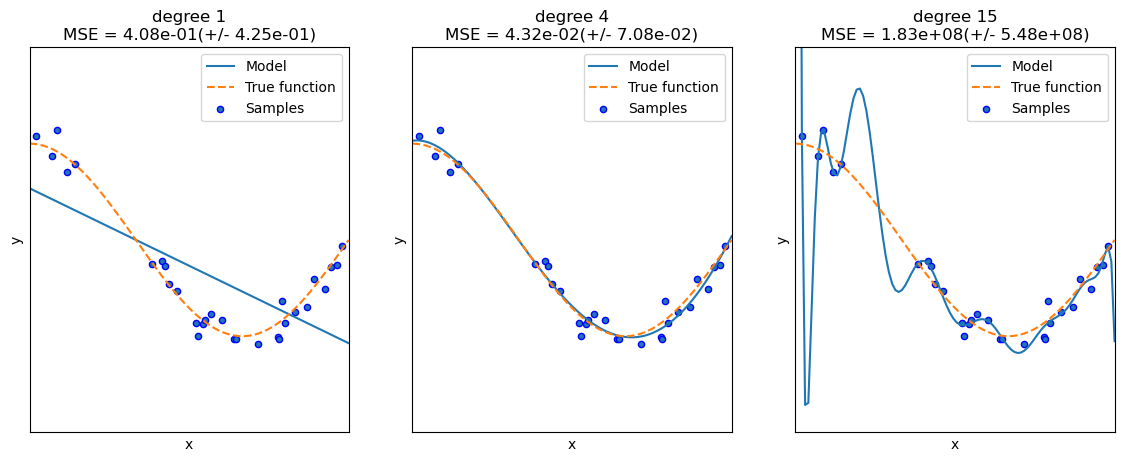

In [6]:
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

# 다항회귀 차수를 1, 4, 15로 각각 변화시키면서 비교
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i+1)
    plt.setp(ax, xticks=(), yticks=())
    
    # 차수별로 Polynomial 변환
    pipeline = Pipeline([('poly', PolynomialFeatures(degree=degrees[i], include_bias=False)),
                        ('linear', LinearRegression())])
    pipeline.fit(X.reshape(-1,1), y)
    
    # 교차검증으로 다항회귀 평가
    scores = -cross_val_score(pipeline, X.reshape(-1,1), y, scoring='neg_mean_squared_error', cv=10)
    # 회귀계수 추출
    print('\ndegree {0} 회귀계수:{1}'.format(degrees[i], np.round(pipeline.named_steps['linear'].coef_, 2)))
    print('degree {0} mse:{1}'.format(degrees[i], np.round(np.mean(scores), 2))) # 교차검증별 mse를 평균냄
    
    # 0부터 1까지 테스트 데이터 세트를 100개로 나눠 예측 수행
    # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교
    X_test = np.linspace(0,1,100)
    # 예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label='Model')
    # 실제값 곡선
    plt.plot(X_test, true_fun(X_test), '--', label='True function')
    # 학습 데이터
    plt.scatter(X, y, edgecolor='b', s=20, label='Samples')
    
    plt.xlabel('x'); plt.ylabel('y'); plt.xlim((0,1)); plt.ylim((-2,2)); plt.legend(loc='best')
    plt.title('degree {0}\nMSE = {1:.2e}(+/- {2:.2e})'.format(degrees[i], scores.mean(), scores.std()))
    
plt.show()

좋은 예측 모델: degree1과 같은 과소적합 모델도 degree15와 같은 과적합 모델이 아닌
            학습데이터의 패턴을 잘 반영하면서도 복잡하지 않은 균형 잡힌(Balanced model)

In [ ]:
[편향-분산 트레이드오프]
과소적합 모델 : 매우 단순화된 모델로 지나치게 한 방향성으로 치우침 - 고편향성
과적합 모델 : 학습 데이터 하나 하나의 특성을 반영하며 높은 변동성 - 고분산성

편향이 높으면 분산은 낮아지고(과소적합) 반대로 분산이 높으면 편향이 낮아짐(과적합)